<a href="https://colab.research.google.com/github/kebalriv25-max/Validacion_hipotesis_de_negocio_con_pruebas_estadisticas/blob/main/S9_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [29]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import levene
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import fisher_exact


In [30]:
# cargar archivo
df = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [31]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [32]:
# información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: Se observa que el dataset no presenta valores nulos, sin embargo el tipo de datos en algunas columnas no son las correctas:
- date: debio ser del tipo datetime pero aparecen como object

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [33]:
df["user_id"].duplicated().sum()

np.int64(0)

 **Variable `date`**  
Explorar rango de fechas

In [34]:
# Resumen estadístico
df["date"].describe()

,date
count,40000
unique,28
top,2026-01-24
freq,1512


In [35]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [36]:
# Resumen estadístico
df["gasto"].describe()

,gasto
count,40000.000000
mean,9.325554
std,25.667986
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,303.680000


In [37]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

,converted
count,40000.00000
mean,0.14265
std,0.34972
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,1.00000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [38]:
# Explorar variables categóricas y cómo se distribuyen
var_categor= ["region","dispositivo","traffic_source","user_type"]

print("\nConteo de categorías:")
for col in var_categor:
    print(f"\n{col} por landing page:")
    print(df.groupby('landing')[col].value_counts(normalize=True))


Conteo de categorías:

region por landing page:
landing  region   
A        Norte        0.277900
         Centro       0.241317
         Sur          0.203283
         Occidente    0.161946
         Oriente      0.115554
B        Norte        0.280398
         Centro       0.239335
         Sur          0.198671
         Occidente    0.157958
         Oriente      0.123639
Name: proportion, dtype: float64

dispositivo por landing page:
landing  dispositivo
A        Mobile         0.621109
         Desktop        0.378891
B        Mobile         0.620342
         Desktop        0.379658
Name: proportion, dtype: float64

traffic_source por landing page:
landing  traffic_source
A        Organic           0.450005
         Ads               0.299319
         Email             0.154489
         Referral          0.096187
B        Organic           0.449346
         Ads               0.297432
         Email             0.151664
         Referral          0.101559
Name: proportion, dtype: f

✍️ **Comentario**:
- Todas las columnas tienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [39]:
# Gasto por versión
gasto_A = df[(df["landing"]=='A') & (df['converted']==1)]["gasto"]
gasto_B = df[(df["landing"]=='B') & (df['converted']==1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencias estadisticamente significativas de una diferencia entre gastos promedios
- **Hipótesis alternativa (H₁):** Existe diferencias estadisticamente significativas de una diferencia entre gastos promedios

In [40]:
#verificacion de varianzas iguales
l_stat, p_value_var = levene(gasto_A, gasto_B)
print("Verificacion de varianzas iguales")
print(f"Estadistico de levene: {l_stat}")
print(f"valor p: {p_value_var}")
print()

alpha = 0.05

if p_value_var < alpha:
    print("Rechazamos la hipotesis nula: hay evidencia de varianzas diferentes (equal_var=False).\n")
else:
    print("No rechazamos la hipotesis nula: no hay evidencia de varianzas diferentes (equal_var=True).\n")


# Aplicar prueba t student con varianzas diferentes
t_stat, p_value = ttest_ind(gasto_A, gasto_B,equal_var=False)

# Visualizar resultados
print("Prueba t de student")
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")
print()

if p_value < alpha:
    print("Rechazamos la hipotesis nula: Existe evidencia estadisticamente significativa de una diferencia entre gastos promedios")
else:
    print("No rechazamos la hipotesis nula: No existe evidencia estadisticamente significativa de una diferencia entre gastos promedios")

Verificacion de varianzas iguales
Estadistico de levene: 29.17646453202917
valor p: 6.875301988016449e-08

Rechazamos la hipotesis nula: hay evidencia de varianzas diferentes (equal_var=False).

Prueba t de student
Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21

Rechazamos la hipotesis nula: Existe evidencia estadisticamente significativa de una diferencia entre gastos promedios


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula.

**Interpretación de negocio:**  
Existe evidencia estadisticamente significativa de una diferencia entre gastos promedios entre los landing page A y B.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe evidencia estadisticamente significativa de una diferencia entre la tasa de conversion entre las landing page A y B.
- **Hipótesis alternativa (H₁):** Existe evidencia estadisticamente significativa de una diferencia entre la tasa de conversion entre las landing page A y B.

In [41]:
# Número de usuarios convertidos por página
numer_convers = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
total_convers = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", numer_convers)
print("\nTotal de usuarios por página:\n", total_convers)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [52]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(numer_convers, total_convers)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados para la hipotesis
alpha = 0.05
if p_value < 0.05:
    print("Rechazamos la hipotesis nula")
else:
    print("No rechazamos la hipotesis nula")

# Calculamos los porcentajes de conversion
tasa_A = numer_convers['A'] / total_convers['A']
tasa_B = numer_convers['B'] / total_convers['B']
print(f"La tasa de conversion de la landing page A: {tasa_A :.2%}")
print(f"La tasa de conversion de la landing page B: {tasa_B :.2%}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipotesis nula
La tasa de conversion de la landing page A: 12.57%
La tasa de conversion de la landing page B: 15.96%


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipotesis nula: Existe evidencia estadisticamente significativa de una diferencia entre la tasa de conversion entre las landing page A y B.

**Interpretación de negocio:**  
La pagina B tiene una mayor tasa de conversion con un valor de 15.96%

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay evidencia estadistica significativa de asociacion entre `traffic_source` y `converted`
- **Hipótesis alternativa (H₁):** Existe evidencia estadistica significativa de asociacion entre `traffic_source` y `converted`

In [43]:
#tabla de contingencia
tabla = pd.crosstab(df["traffic_source"],df["converted"])
# verificamos proporciones
pd.crosstab(df["traffic_source"],df["converted"],normalize='index')*100

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [44]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadistico chi-cuadrado: {chi2_stat:.2f}")
print(f"Valor P: {p_value:.2f}")
print("\nFrecuencias esperadas:")
print(expected)

Estadistico chi-cuadrado: 8.66
Valor P: 0.03

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [45]:
# Evaluando lumbrales
alpha = 0.05

if p_value < alpha:
    print("Rechazamos la hipotesis nula: Hay evidencia de asociacion entre las variables")
else:
    print("No rechazamos la hipotesis nula: No hay evidencia suficiente de asociacion entre las variables")


Rechazamos la hipotesis nula: Hay evidencia de asociacion entre las variables


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipotesis nula.

**Interpretación de negocio:**  
- Con base en un chi-square test de independencia, encontramos evidencia estadistica significativa de asociacion entre `traffic_source` y `converted`.
- Evidenciando que existe mayor tasa de conversion en los usuarios por `email` con un 14.99%


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba de Fisher

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay evidencia estadistica significativa de asociacion entre `user_type` y `converted`
- **Hipótesis alternativa (H₁):** Existe evidencia estadistica significativa de asociacion entre `user_type` y `converted`

In [46]:
tabla_2x2 = pd.crosstab(df["user_type"],df["converted"])

In [47]:
# Aplicar prueba
odds_ratio, p_value = fisher_exact(tabla_2x2)
print(f"Odd Ratio: {odds_ratio:.3f}")
print(f"Valor P (Fisher): {p_value:.3f}")

# Interpretacion
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipotesis nula: Hay evidencia de asociacion entre las variables")
else:
    print("No rechazamos la hipotesis nula: No hay evidencia suficiente de asociacion entre las variables")



Odd Ratio: 0.978
Valor P (Fisher): 0.472
No rechazamos la hipotesis nula: No hay evidencia suficiente de asociacion entre las variables


### 📝 Conclusión e interpretación

**Decisión:**  
No rechazamos la hipotesis nula.

**Interpretación de negocio:**  
No hay evidencia estadistica significativa de asociacion entre `user_type` y `converted`, los perfiles de usuario convierten de manera similar, y no es necesario priorizar un tipo de usuario específico para mejorar la tasa de conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

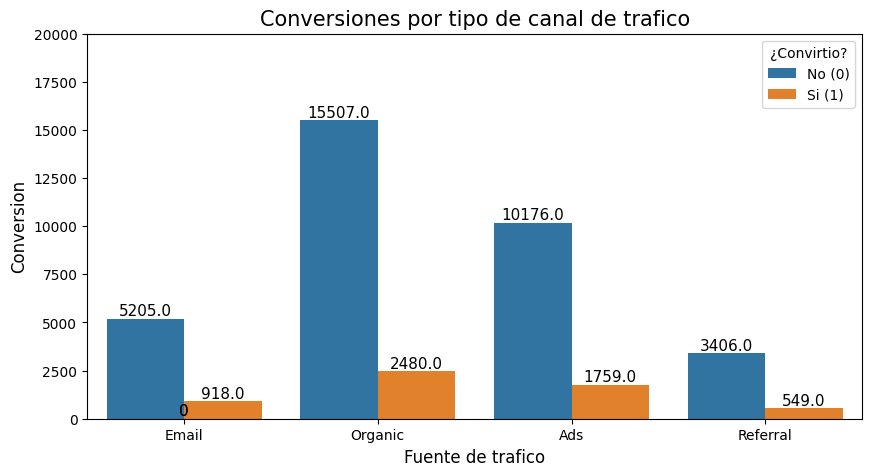

In [48]:
# Grafico de barras agrupadas
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x="traffic_source", hue="converted")
# Agregar valores
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2, y=height, s=height, ha='center'
            ,va='bottom', fontsize=11)
# Añadir detalles
plt.title("Conversiones por tipo de canal de trafico", fontsize=15)
plt.xlabel("Fuente de trafico", fontsize=12)
plt.ylabel("Conversion", fontsize=12)
plt.ylim(0,20000)
plt.legend(title="¿Convirtio?", labels=['No (0)','Si (1)'])
plt.show()


✍️ **Comentario**: Podemos apreciar que el mayor volumen de conversion se da en los usuarios que llegaron de forma organica. El menor volumen de conversion se da en los usuarios del tipo referido.


### Relación entre el tipo de usuario y la conversión

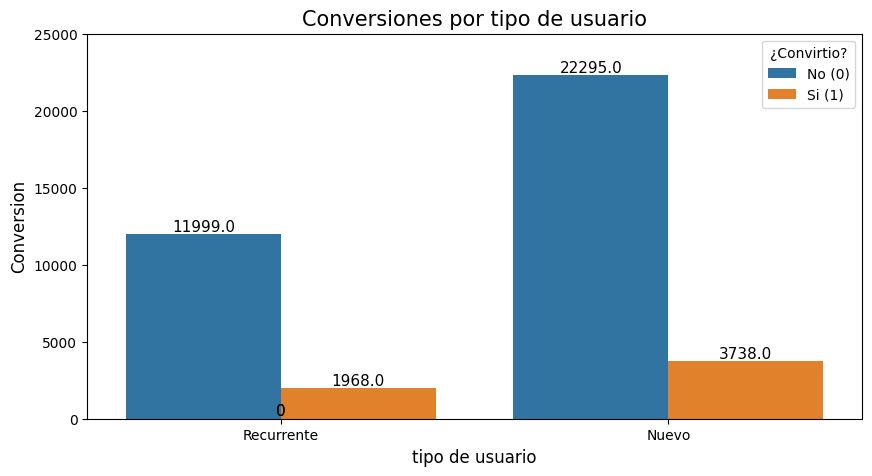

In [49]:
# Grafico de barras agrupadas
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x="user_type", hue="converted")
# Agregar valores
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width() /2, y=height, s=height, ha='center'
            ,va='bottom', fontsize=11)
# Añadir detalles
plt.title("Conversiones por tipo de usuario", fontsize=15)
plt.xlabel("tipo de usuario", fontsize=12)
plt.ylabel("Conversion", fontsize=12)
plt.ylim(0,25000)
plt.legend(title="¿Convirtio?", labels=['No (0)','Si (1)'])
plt.show()


✍️ **Comentario**: Podemos apreciar que el mayor volumen de conversion se da en los usuarios nuevos.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La prueba de Levene detectó varianzas significativamente distintas entre ambos grupos, lo que llevó a aplicar la prueba t con varianzas desiguales.
- La diferencia en gasto promedio entre páginas A y B es estadísticamente significativa, la página B genera un gasto promedio por usuario convertido mayor que la página A.
  
- **Interpretación:**
Desde la perspectiva de ingresos por usuario, la página B es claramente superior a la página A.
<br>

**Tasa de conversión:**
- La prueba Z arrojó nos muestra que se debe rechazar la hipótesis nula con alta confianza.
- Las tasas de conversion fueron en la Página A: 12.57% vs. Página B: 15.96% existiendo una diferencia absoluta de +3.39 puntos porcentuales a favor de B.
- **Interpretación:**
La página B convierte aproximadamente un 27% más de usuarios que la página A. La página B es la versión ganadora del experimento en ambas métricas
---

#### 📊 **Segmentación por fuente de tráfico**
- La prueba Chi-cuadrado encontró evidencia estadísticamente significativa de asociación entre la fuente de tráfico y la tasa de conversión.
- Se evidencia que por tasa de conversión proporcional: Email (14.99%) > Ads (14.74%) > Referral (13.88%) > Organic (13.79%). Por volumen absoluto de conversiones: el canal Organic lidera, al representar 45% del total del tráfico.
- **Interpretación:**
 En base a la evidencia estadistica presentada, el canal Email es el más eficiente, lo que sugiere que los usuarios captados por este canal llegan con mayor intención de compra. Organic genera el mayor volumen absoluto, pero con menor eficiencia proporcional. Referral presenta la menor eficiencia de conversión .
 ---

#### 📊 **Segmentación por tipo de usuario**
- La prueba exacta de Fisher arrojó un Odd Ratio de 0.978 y un p-valor de 0.472 por tanto no se rechaza la hipótesis nula.
- Las proporciones de usuarios nuevos (65%) y recurrentes (35%) son similares en ambas páginas, y sus tasas de conversión no difieren significativamente.
- **Interpretación:**
El tipo de usuario (Nuevo vs. Recurrente) no es un factor diferenciador en la conversión dentro de este experimento. Ambos perfiles responden de manera equivalente a las páginas A y B, por lo que no es necesario personalizar la experiencia por este segmento.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- La evidencia estadistica obtenida nos sugiere adoptar la Página B como posible version definitiva. Con una tasa de conversión un 27% superior y un gasto promedio significativamente mayor, la página B representa un impacto directo en los ingresos. Se recomienda desplegar la página B al 100% del tráfico a la brevedad posible.
- Realizar un analisis de costos para poder evaluar si invertir en el canal Email es factible por ser el canal con la mayor tasa de conversión proporcional (14.99%), de ser el caso, se recomienda aumentar la inversión en campañas de email marketing asi como diseñar flujos automatizados con la nueva página B puede maximizar el retorno de inversión.